In [6]:
import pandas as pd
from pathlib import Path
import os

In [7]:
# Define our data paths based on your folder structure
data_dir = Path("../data/raw/CSV Files")
train_test_dir = data_dir / "Training and Testing Sets"

print("--- RAW DATA FILES ---")
raw_files = list(data_dir.glob("UNSW-NB15_[1-4].csv"))
for file in raw_files:
    size_mb = os.path.getsize(file) / (1024 * 1024)
    # Read just the first 5 rows to get the shape without loading the whole file
    df_preview = pd.read_csv(file, header=None, nrows=5) 
    print(f"{file.name}: {size_mb:.2f} MB | Columns: {df_preview.shape[1]}")

print("\n--- PRE-SPLIT DATA FILES ---")
split_files = list(train_test_dir.glob("*.csv"))
for file in split_files:
    size_mb = os.path.getsize(file) / (1024 * 1024)
    df_preview = pd.read_csv(file, nrows=5)
    print(f"{file.name}: {size_mb:.2f} MB | Columns: {df_preview.shape[1]}")

print("\n--- METADATA FILES ---")
features_file = data_dir / "NUSW-NB15_features.csv"
if features_file.exists():
    df_features = pd.read_csv(features_file, encoding='cp1252') # Often needs specific encoding
    print(f"Features metadata loaded. Found {len(df_features)} feature descriptions.")

--- RAW DATA FILES ---
UNSW-NB15_1.csv: 161.15 MB | Columns: 49
UNSW-NB15_2.csv: 157.57 MB | Columns: 49
UNSW-NB15_3.csv: 147.43 MB | Columns: 49
UNSW-NB15_4.csv: 93.07 MB | Columns: 49

--- PRE-SPLIT DATA FILES ---
UNSW_NB15_testing-set.csv: 14.67 MB | Columns: 45
UNSW_NB15_training-set.csv: 30.80 MB | Columns: 45

--- METADATA FILES ---


# DATA STRATEGY & LOADING

In [8]:
# Load the official pre-split datasets
train_file = train_test_dir / "UNSW_NB15_training-set.csv"
test_file = train_test_dir / "UNSW_NB15_testing-set.csv"
df_train = pd.read_csv(train_file)
df_test = pd.read_csv(test_file)

In [9]:
print("\n--- DATASET SHAPES ---")
print(f"Training Data: {df_train.shape[0]:,} rows, {df_train.shape[1]} columns")
print(f"Testing Data:  {df_test.shape[0]:,} rows, {df_test.shape[1]} columns")


--- DATASET SHAPES ---
Training Data: 175,341 rows, 45 columns
Testing Data:  82,332 rows, 45 columns


In [10]:
print("\n--- MISSING VALUES (NaNs) ---")
train_missing = df_train.isna().sum().sum()
test_missing = df_test.isna().sum().sum()
print(f"Total missing values in Train: {train_missing}")
print(f"Total missing values in Test:  {test_missing}")


--- MISSING VALUES (NaNs) ---
Total missing values in Train: 0
Total missing values in Test:  0


In [11]:
print("\n--- TARGET VARIABLES ---")
print("Train labels (0=Normal, 1=Attack):")
print(df_train['label'].value_counts(normalize=True) * 100)

print("\nTrain Attack Categories:")
print(df_train['attack_cat'].value_counts())


--- TARGET VARIABLES ---
Train labels (0=Normal, 1=Attack):
label
1    68.062233
0    31.937767
Name: proportion, dtype: float64

Train Attack Categories:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


# DATA CLEANING & VALIDATION

In [12]:
import numpy as np

## DUPLICATE CHECK

In [13]:
train_dupes = df_train.duplicated().sum()
test_dupes = df_test.duplicated().sum()
print(f"Exact duplicates in Train: {train_dupes}")
print(f"Exact duplicates in Test:  {test_dupes}")

# Remove duplicates from training data (but NOT test data, to preserve the benchmark)
df_train = df_train.drop_duplicates()
print(f"Train shape after dropping duplicates: {df_train.shape}")

Exact duplicates in Train: 0
Exact duplicates in Test:  0
Train shape after dropping duplicates: (175341, 45)


## HIDDEN NULLS ('-') CHECK

In [14]:
# Let's look at the 'service' column
print("Top 5 categories in 'service' before cleaning:")
print(df_train['service'].value_counts().head(5))

Top 5 categories in 'service' before cleaning:
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
Name: count, dtype: int64


In [15]:
# Replace '-' with 'None' (which is more descriptive for an unknown service)
df_train['service'] = df_train['service'].replace('-', 'None')
df_test['service'] = df_test['service'].replace('-', 'None')

print("\nTop 5 categories in 'service' after cleaning:")
print(df_train['service'].value_counts().head(5))


Top 5 categories in 'service' after cleaning:
service
None        94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
Name: count, dtype: int64


## INFINITE VALUES CHECK

In [16]:
# Identify numerical columns
num_cols = df_train.select_dtypes(include=[np.number]).columns

# Check for infinity
train_inf = np.isinf(df_train[num_cols]).values.sum()
print(f"Total infinite values in Train: {train_inf}")

Total infinite values in Train: 0


# DATA LEAKAGE AUDIT & ID REMOVAL

## ID COLUMN REMOVAL

In [17]:
# Check if 'id' exists and drop it
if 'id' in df_train.columns:
    df_train = df_train.drop(columns=['id'])
    df_test = df_test.drop(columns=['id'])
    print("Dropped 'id' column from both Train and Test to prevent data leakage.")
else:
    print("'id' column not found. It may have been dropped already.")

Dropped 'id' column from both Train and Test to prevent data leakage.


## TRUE DUPLICATE CHECK

In [18]:
# Now that 'id' is gone, let's see how many rows are ACTUALLY identical
train_dupes_real = df_train.duplicated().sum()
print(f"REAL exact duplicates in Train (without ID): {train_dupes_real}")

# Drop the real duplicates from the training set
if train_dupes_real > 0:
    df_train = df_train.drop_duplicates()
    print(f"Train shape after dropping REAL duplicates: {df_train.shape}")

REAL exact duplicates in Train (without ID): 67601
Train shape after dropping REAL duplicates: (107740, 44)


# EXPLORATORY DATA ANALYSIS (EDA)

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# 1. Checkpoint our cleaned data
df_train.to_csv('../data/processed/cleaned_train.csv', index=False)
df_test.to_csv('../data/processed/cleaned_test.csv', index=False)
print("Saved cleaned datasets to data/processed/")

# Set plot style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

Saved cleaned datasets to data/processed/


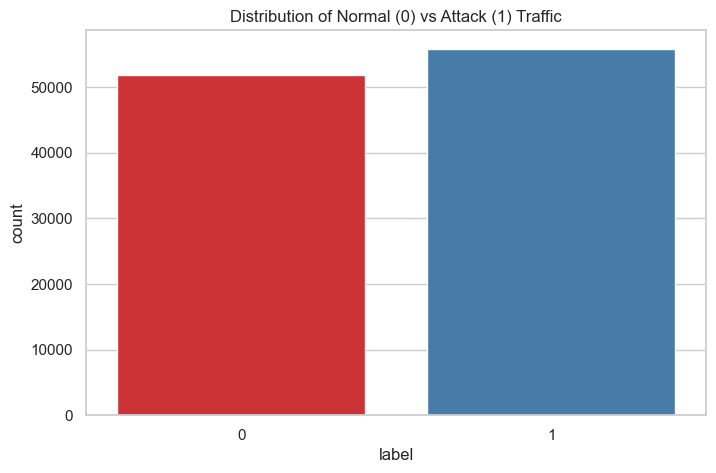

In [21]:
# 2. Binary Target Distribution 
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x='label', hue='label', palette='Set1', legend=False)
plt.title('Distribution of Normal (0) vs Attack (1) Traffic')
plt.show()

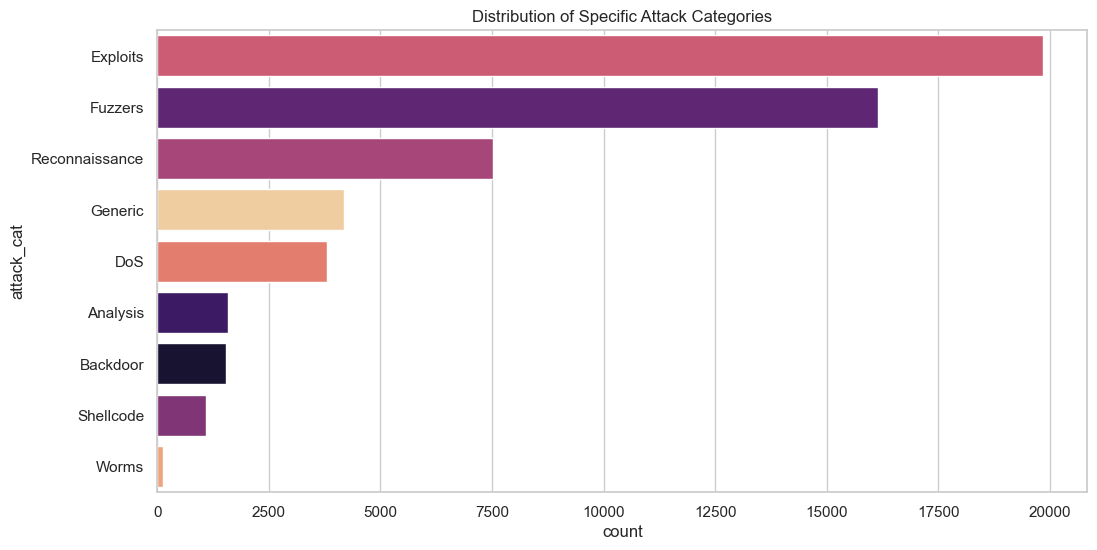

In [22]:
# 3. Multiclass Target Distribution 
plt.figure(figsize=(12, 6))
attacks_only = df_train[df_train['label'] == 1]
sns.countplot(data=attacks_only, y='attack_cat', hue='attack_cat', 
              order=attacks_only['attack_cat'].value_counts().index, 
              palette='magma', legend=False)
plt.title('Distribution of Specific Attack Categories')
plt.show()

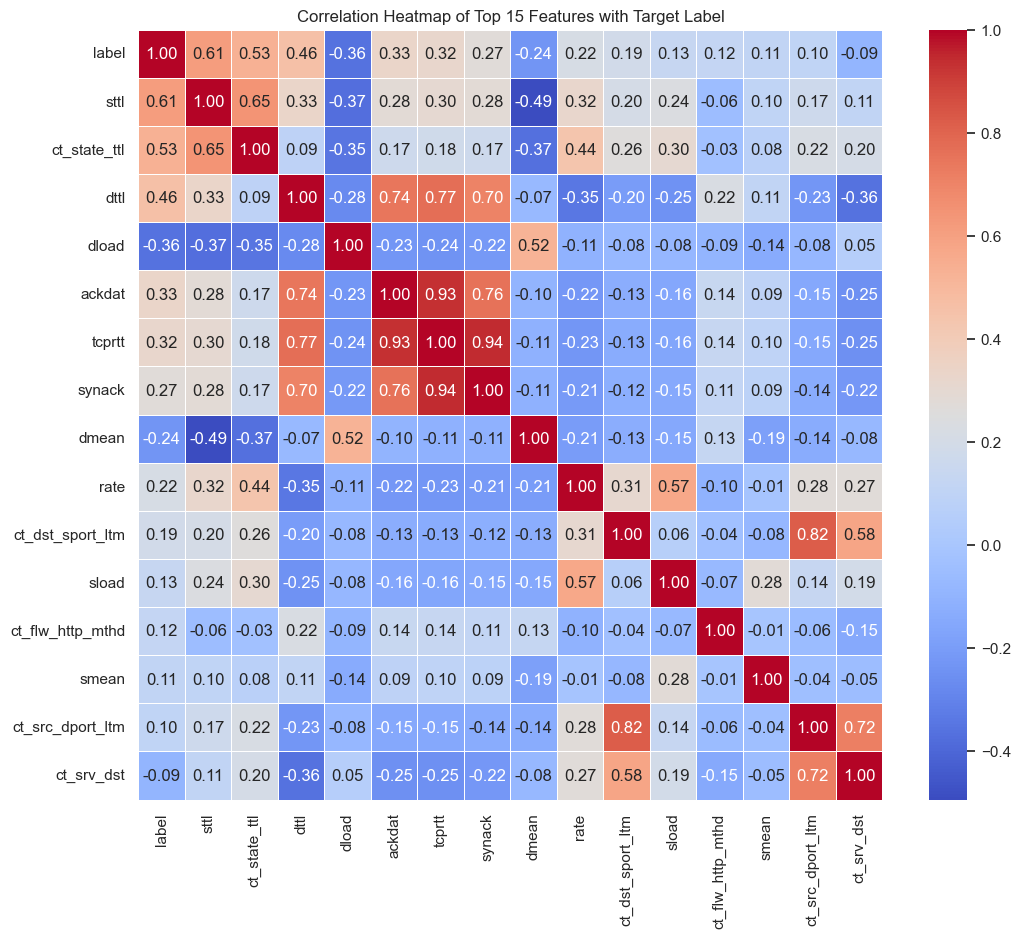

In [23]:
# 4. Correlation Heatmap
# Select only numerical columns
num_cols = df_train.select_dtypes(include=[np.number])
# Calculate the correlation matrix
corr_matrix = num_cols.corr()
# Find the 15 features most correlated with the 'label'
top_corr_features = corr_matrix['label'].abs().sort_values(ascending=False).head(16).index

plt.figure(figsize=(12, 10))
sns.heatmap(df_train[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Top 15 Features with Target Label')
plt.show()

# OUTLIER ANALYSIS & FEATURE ENGINEERING

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd

## SEPARATING FEATURES AND TARGET

In [25]:
# Drop the labels from X
X_train = df_train.drop(columns=['label', 'attack_cat'])
y_train_bin = df_train['label']
y_train_multi = df_train['attack_cat']

X_test = df_test.drop(columns=['label', 'attack_cat'])
y_test_bin = df_test['label']
y_test_multi = df_test['attack_cat']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (107740, 42)
X_test shape:  (82332, 42)


## BUILDING THE PREPROCESSING PIPELINE

In [26]:
# Identify column types
cat_cols = ['proto', 'service', 'state']
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Define the transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

print("Fitting preprocessor on training data ONLY...")
X_train_processed = preprocessor.fit_transform(X_train)

print("Applying the learned transformation to test data...")
X_test_processed = preprocessor.transform(X_test)

Fitting preprocessor on training data ONLY...
Applying the learned transformation to test data...


In [27]:
# Convert the Numpy arrays back to Pandas DataFrames so we can see the new column names
feature_names = num_cols + list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols))
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

## FEATURE ENGINEERING RESULTS

In [28]:
print(f"Original feature count:  {len(num_cols) + len(cat_cols)}")
print(f"Processed feature count: {X_train_df.shape[1]}")

Original feature count:  42
Processed feature count: 194


In [29]:
print("First 3 rows of processed training data:")
display(X_train_df.head(3))

First 3 rows of processed training data:


,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,service_ssl,state_CON,state_ECO,state_FIN,state_INT,state_PAR,state_REQ,state_RST,state_URN,state_no
0,-0.223580,-0.139493,-0.190846,-0.060940,-0.131903,-0.331102,1.010875,1.141228,-0.234937,-0.358601,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.127877,-0.093361,0.058156,-0.058802,0.102349,-0.331064,-0.752046,1.123989,-0.234965,-0.194330,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.048383,-0.127960,-0.102963,-0.060464,-0.059044,-0.331616,-0.752046,1.123989,-0.234997,-0.341203,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


# MUTUAL INFORMATION FEATURE SELECTION

In [30]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest

## CALCULATING MUTUAL INFORMATION

In [31]:
# Configure SelectKBest to keep the top 40 features
mi_selector = SelectKBest(score_func=mutual_info_classif, k=40)

print("Fitting MI selector on training data... (This may take 1-2 minutes, please wait)")
# Fit using the binary target (Normal vs Attack)
X_train_selected = mi_selector.fit_transform(X_train_df, y_train_bin)

print("Applying feature selection to test data...")
X_test_selected = mi_selector.transform(X_test_df)

# Retrieve the names of the columns that survived the cut
selected_mask = mi_selector.get_support()
selected_features = X_train_df.columns[selected_mask]

# Rebuild Pandas DataFrames with the selected features
X_train_sel_df = pd.DataFrame(X_train_selected, columns=selected_features)
X_test_sel_df = pd.DataFrame(X_test_selected, columns=selected_features)

print(f"\nSuccess! Reduced feature count from {X_train_df.shape[1]} down to {X_train_sel_df.shape[1]}.")

Fitting MI selector on training data... (This may take 1-2 minutes, please wait)
Applying feature selection to test data...

Success! Reduced feature count from 194 down to 40.


## TOP 15 PREDICTIVE FEATURES

Top 15 Features and their MI Scores:
sbytes          0.460457
dbytes          0.419047
sttl            0.408311
dttl            0.395524
ct_state_ttl    0.389739
dmean           0.330531
rate            0.313829
smean           0.303519
dinpkt          0.301513
dur             0.285033
tcprtt          0.284736
synack          0.283106
ackdat          0.281056
dpkts           0.274859
dload           0.267925
dtype: float64


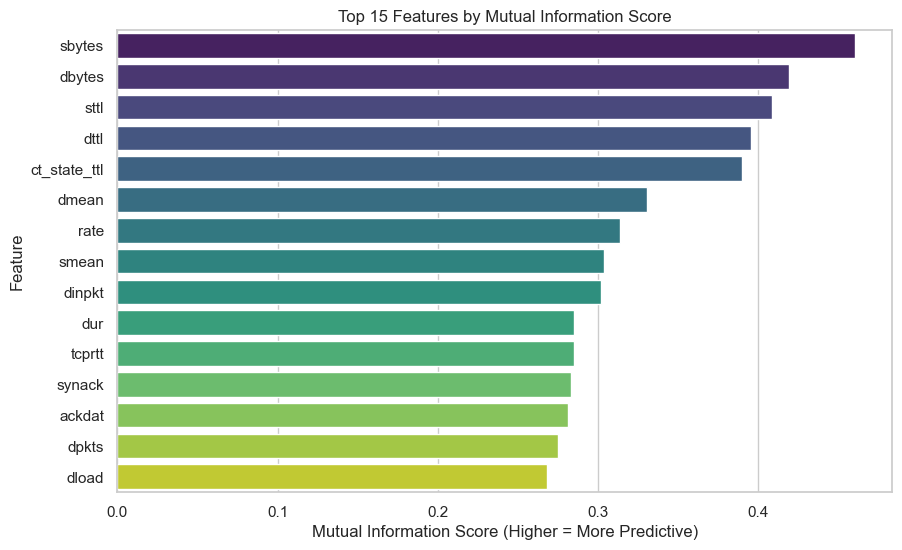

In [32]:
# Map the MI scores back to the original feature names
mi_scores = pd.Series(mi_selector.scores_, index=X_train_df.columns)
mi_scores_sorted = mi_scores.sort_values(ascending=False)

print("Top 15 Features and their MI Scores:")
print(mi_scores_sorted.head(15))

# Visualize the top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_scores_sorted.head(15).values, 
            y=mi_scores_sorted.head(15).index, 
            hue=mi_scores_sorted.head(15).index,
            palette='viridis', 
            legend=False)
plt.title("Top 15 Features by Mutual Information Score")
plt.xlabel("Mutual Information Score (Higher = More Predictive)")
plt.ylabel("Feature")
plt.show()

# CLASS IMBALANCE & TRAIN/VALIDATION STRATEGY

In [33]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

## CREATING VALIDATION SET

In [34]:
# Split the current training data into Train (80%) and Validation (20%)
# 'stratify=y_train_multi' ensures the 80/20 split maintains the exact same ratio of attacks
X_train_final, X_val, y_train_multi_final, y_val_multi = train_test_split(
    X_train_sel_df, y_train_multi, test_size=0.2, random_state=42, stratify=y_train_multi
)

# We also need the binary labels split the exact same way for our binary models later
_, _, y_train_bin_final, y_val_bin = train_test_split(
    X_train_sel_df, y_train_bin, test_size=0.2, random_state=42, stratify=y_train_multi
)

print(f"Final Training Set: {X_train_final.shape[0]:,} rows")
print(f"Validation Set:     {X_val.shape[0]:,} rows")
print(f"Untouched Test Set: {X_test_sel_df.shape[0]:,} rows")

Final Training Set: 86,192 rows
Validation Set:     21,548 rows
Untouched Test Set: 82,332 rows


## APPLYING SMOTE TO TRAINING DATA ONLY

In [35]:
print("Class distribution BEFORE SMOTE (Bottom 3 classes):")
print(y_train_multi_final.value_counts().tail(3))

# Initialize SMOTE
smote = SMOTE(random_state=42)
print("\nGenerating synthetic network flows... (This may take a moment)")
X_train_smote, y_train_multi_smote = smote.fit_resample(X_train_final, y_train_multi_final)

# We also apply SMOTE to the binary target for our binary models
X_train_bin_smote, y_train_bin_smote = smote.fit_resample(X_train_final, y_train_bin_final)

print("\nMulticlass distribution AFTER SMOTE:")
print(y_train_multi_smote.value_counts())
print(f"\nNew SMOTE Training Set Shape: {X_train_smote.shape}")

Class distribution BEFORE SMOTE (Bottom 3 classes):
attack_cat
Backdoor     1228
Shellcode     873
Worms         101
Name: count, dtype: int64

Generating synthetic network flows... (This may take a moment)

Multiclass distribution AFTER SMOTE:
attack_cat
Normal            41512
Reconnaissance    41512
Exploits          41512
DoS               41512
Generic           41512
Backdoor          41512
Fuzzers           41512
Analysis          41512
Shellcode         41512
Worms             41512
Name: count, dtype: int64

New SMOTE Training Set Shape: (415120, 40)


# BASELINE & MACHINE LEARNING


In [37]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score
import time

## BASELINE MODEL (DUMMY CLASSIFIER)

In [38]:
dummy = DummyClassifier(strategy='prior')
dummy.fit(X_train_bin_smote, y_train_bin_smote)
dummy_preds = dummy.predict(X_val)

print("Baseline Validation Performance:")
print(f"Accuracy: {accuracy_score(y_val_bin, dummy_preds):.4f}")
print(classification_report(y_val_bin, dummy_preds, target_names=['Normal (0)', 'Attack (1)'], zero_division=0))

Baseline Validation Performance:
Accuracy: 0.4816
              precision    recall  f1-score   support

  Normal (0)       0.48      1.00      0.65     10378
  Attack (1)       0.00      0.00      0.00     11170

    accuracy                           0.48     21548
   macro avg       0.24      0.50      0.33     21548
weighted avg       0.23      0.48      0.31     21548



## RANDOM FOREST CLASSIFIER

In [39]:
start_time = time.time()
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
print("Training Random Forest... (Please wait)")
rf_model.fit(X_train_bin_smote, y_train_bin_smote)
rf_train_time = time.time() - start_time

rf_preds = rf_model.predict(X_val)
print(f"Training Time: {rf_train_time:.2f} seconds")
print("\nRandom Forest Validation Performance:")
print(classification_report(y_val_bin, rf_preds, target_names=['Normal (0)', 'Attack (1)']))

Training Random Forest... (Please wait)
Training Time: 42.60 seconds

Random Forest Validation Performance:
              precision    recall  f1-score   support

  Normal (0)       0.95      0.92      0.93     10378
  Attack (1)       0.92      0.95      0.94     11170

    accuracy                           0.93     21548
   macro avg       0.94      0.93      0.93     21548
weighted avg       0.93      0.93      0.93     21548



## XGBOOST CLASSIFIER

In [40]:
start_time = time.time()
# XGBoost requires targets to be strictly 0 and 1 (which ours are)
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
print("Training XGBoost... (Please wait)")
xgb_model.fit(X_train_bin_smote, y_train_bin_smote)
xgb_train_time = time.time() - start_time

xgb_preds = xgb_model.predict(X_val)
print(f"Training Time: {xgb_train_time:.2f} seconds")
print("\nXGBoost Validation Performance:")
print(classification_report(y_val_bin, xgb_preds, target_names=['Normal (0)', 'Attack (1)']))

Training XGBoost... (Please wait)
Training Time: 16.38 seconds

XGBoost Validation Performance:
              precision    recall  f1-score   support

  Normal (0)       0.95      0.91      0.93     10378
  Attack (1)       0.92      0.95      0.94     11170

    accuracy                           0.93     21548
   macro avg       0.93      0.93      0.93     21548
weighted avg       0.93      0.93      0.93     21548



# MULTICLASS CLASSIFICATION & CONFUSION MATRIX

In [41]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

## ENCODING MULTICLASS LABELS

In [42]:
le = LabelEncoder()
# Fit on the validation set classes just to ensure we capture all names, but transform both
le.fit(y_val_multi)
y_train_multi_encoded = le.transform(y_train_multi_smote)
y_val_multi_encoded = le.transform(y_val_multi)

print(f"Classes encoded: {le.classes_}")

Classes encoded: ['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']


## TRAINING MULTICLASS XGBOOST

In [43]:
start_time = time.time()
# Objective 'multi:softprob' is used for multiclass classification
xgb_multi = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    objective='multi:softprob', 
    random_state=42, 
    n_jobs=-1
)

print("Training XGBoost Multiclass Model... (This will take longer than binary!)")
xgb_multi.fit(X_train_smote, y_train_multi_encoded)
print(f"Training Time: {time.time() - start_time:.2f} seconds")

Training XGBoost Multiclass Model... (This will take longer than binary!)
Training Time: 449.05 seconds


## Validation Performance

In [45]:
multi_preds_encoded = xgb_multi.predict(X_val)

# Decode predictions back to text for readable reports
multi_preds_text = le.inverse_transform(multi_preds_encoded)

print(classification_report(y_val_multi, multi_preds_text, zero_division=0))

                precision    recall  f1-score   support

      Analysis       0.17      0.56      0.26       319
      Backdoor       0.19      0.42      0.26       307
           DoS       0.40      0.29      0.33       761
      Exploits       0.87      0.75      0.80      3969
       Fuzzers       0.65      0.83      0.73      3230
       Generic       0.95      0.84      0.89       836
        Normal       0.98      0.84      0.91     10378
Reconnaissance       0.83      0.78      0.80      1504
     Shellcode       0.38      0.93      0.54       218
         Worms       0.14      0.73      0.23        26

      accuracy                           0.79     21548
     macro avg       0.56      0.70      0.58     21548
  weighted avg       0.85      0.79      0.81     21548



## CONFUSION MATRIX

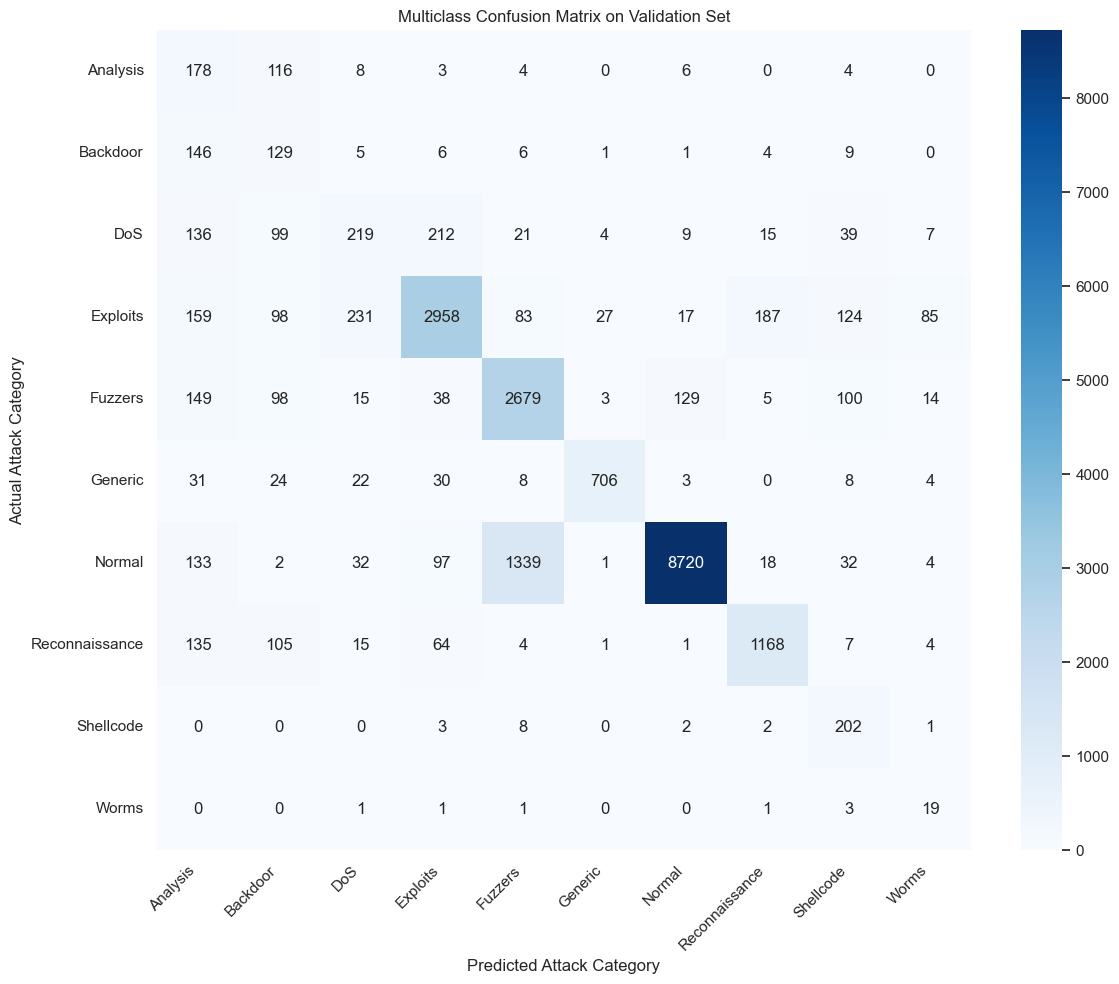

In [47]:
cm = confusion_matrix(y_val_multi, multi_preds_text, labels=le.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Multiclass Confusion Matrix on Validation Set')
plt.ylabel('Actual Attack Category')
plt.xlabel('Predicted Attack Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# HYPERPARAMETER TUNING & SHAP EXPLAINABILITY

In [50]:
from sklearn.model_selection import RandomizedSearchCV
import shap
import time

# HYPERPARAMETER TUNING (BINARY XGBOOST)

In [51]:
# Define the hyperparameter search space
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'subsample': [0.8, 1.0]
}

# Initialize the base model
xgb_base = xgb.XGBClassifier(random_state=42, n_jobs=-1)

# Initialize Randomized Search (Cross-Validation = 3, Iterations = 3 to save time)
random_search = RandomizedSearchCV(
    estimator=xgb_base, 
    param_distributions=param_grid, 
    n_iter=3, 
    scoring='f1', 
    cv=3, 
    verbose=1, 
    random_state=42
)

start_time = time.time()
print("Searching for the best hyperparameters... (This trains 9 models, please wait)")
random_search.fit(X_train_bin_smote, y_train_bin_smote)
print(f"Tuning Time: {time.time() - start_time:.2f} seconds")

Searching for the best hyperparameters... (This trains 9 models, please wait)
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Tuning Time: 80.55 seconds


In [52]:
# Extract the best model
best_xgb = random_search.best_estimator_
print(f"\nBest Hyperparameters Found: {random_search.best_params_}")


Best Hyperparameters Found: {'subsample': 1.0, 'n_estimators': 50, 'max_depth': 7, 'learning_rate': 0.2}


In [53]:
# Score the tuned model
tuned_preds = best_xgb.predict(X_val)
print("\nTuned Model Validation Performance:")
print(classification_report(y_val_bin, tuned_preds, target_names=['Normal (0)', 'Attack (1)']))

print("\n--- 2. SHAP EXPLAINABILITY ---")
print("Calculating SHAP values... (Using a sample of 1000 rows to save time)")


Tuned Model Validation Performance:
              precision    recall  f1-score   support

  Normal (0)       0.95      0.92      0.93     10378
  Attack (1)       0.92      0.95      0.94     11170

    accuracy                           0.93     21548
   macro avg       0.94      0.93      0.93     21548
weighted avg       0.93      0.93      0.93     21548


--- 2. SHAP EXPLAINABILITY ---
Calculating SHAP values... (Using a sample of 1000 rows to save time)


In [54]:
# Initialize the SHAP explainer with our best model
explainer = shap.TreeExplainer(best_xgb)

In [55]:
# Take a random sample of the validation set to explain
X_val_sample = X_val.sample(1000, random_state=42)

# Calculate SHAP values
shap_values = explainer.shap_values(X_val_sample)

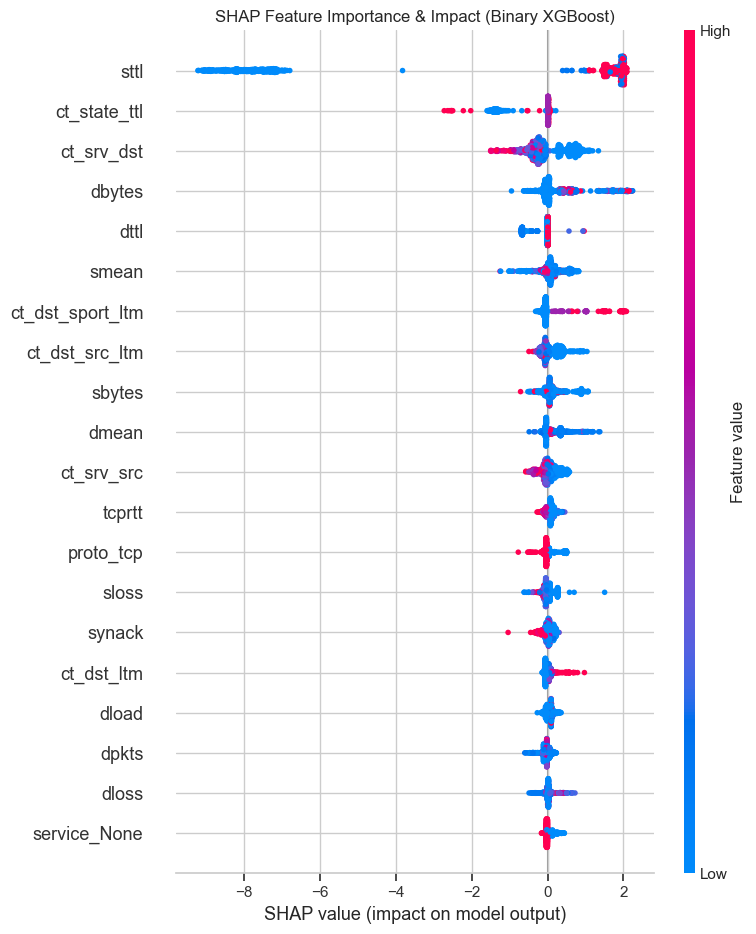

In [56]:
# Plot the global summary
plt.figure(figsize=(10, 8))
plt.title("SHAP Feature Importance & Impact (Binary XGBoost)")
shap.summary_plot(shap_values, X_val_sample, show=True)